In [ ]:
from btree import BTree
import random
ORDER = 10
bt = BTree[int](ORDER)

insert_log = []
for i in range(1000):
    # Insert random numbers into the B-tree
    to_insert = random.randint(1, 100000)
    insert_log.append(to_insert)
    bt.insert(to_insert)

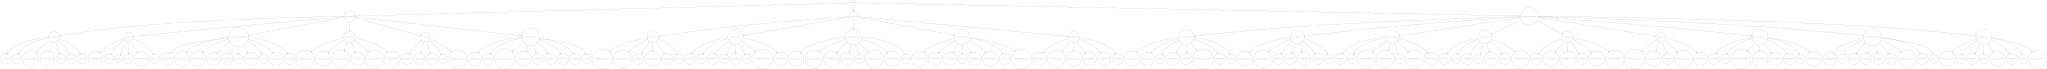

In [14]:
from graphviz import Digraph
from IPython.display import display, SVG

def visualize_btree(btree):
    dot = Digraph()
    # Set some global node defaults:
    dot.attr('node',
             shape='circle',
             fontsize='10')      # smaller font

    def add_nodes_edges(node, parent=None):
        if node is None:
            return

        node_id = str(id(node))
        # Format label as just the comma-separated keys
        label = ", ".join(str(k) for k in node.keys)
        dot.node(node_id, label=label)

        if parent is not None:
            dot.edge(str(id(parent)), node_id)

        for child in node.children:
            add_nodes_edges(child, node)

    add_nodes_edges(btree.root)
    return dot

# Usage:
dot = visualize_btree(bt)
dot.format = 'svg'
display(SVG(dot.pipe()))


In [ ]:
len(bt.root.children[3].children)

0

In [3]:
ll = [16, 167, 178, 282, 355, 653, 656, 785, 894, 910]
middle_idx = len(ll) // 2

print(ll)

middle_key = ll.pop(middle_idx)
print(middle_key)

lhs = ll[:middle_idx]
rhs = ll[middle_idx:]
print(lhs, rhs)

[16, 167, 178, 282, 355, 653, 656, 785, 894, 910]
653
[16, 167, 178, 282, 355] [656, 785, 894, 910]


In [4]:
from btree import BTree
import random

# … your existing code to build bt and insert_log …
# bt = BTree
# insert_log = [...]
# for i in range(1000):
#     x = random.randint(1, 10000)
#     insert_log.append(x)
#     bt.insert(x)

def inorder_traversal(node):
    """Return a flat list of keys from an in-order traversal of this node."""
    result = []
    # For each key, first traverse its left child (if any), then the key itself
    for i, key in enumerate(node.keys):
        if node.children:
            result.extend(inorder_traversal(node.children[i]))
        result.append(key)
    # Finally, traverse the rightmost child
    if node.children:
        result.extend(inorder_traversal(node.children[-1]))
    return result

def valid_key_count(node):
    bad_node = None
    if len(node.keys) < (node.order - 1) // 2 or len(node.keys) > node.order - 1:
        bad_node = node.keys

    for i, key in enumerate(node.keys):
        if node.children:
            bad_node = valid_key_count(node.children[i])
            if bad_node:
                return bad_node
    if node.children:
        bad_node = valid_key_count(node.children[-1])
    return bad_node

def validate_btree(bt: BTree[int], insert_log: list[int]):
    # 1) Existence
    missing = [x for x in insert_log if not bt.exists(x)]
    if missing:
        print(f"ERROR: {len(missing)} values not found in tree! Sample missing: {missing[:10]}")
    else:
        print("✓ All inserted values exist in the B-tree.")
    # 1.5) Non-Existence
    not_inserted = [x for x in random.sample(range(1, 10001), 100) if x not in insert_log]
    false_positives = [x for x in not_inserted if bt.exists(x)]
    if false_positives:
        print(f"ERROR: {len(false_positives)} values incorrectly found in tree! Sample: {false_positives[:10]}")
    else:
        print("✓ All non-inserted values correctly not found in the B-tree.")

    # 2) Valid # of keys in each node
    bad_node = valid_key_count(bt.root)
    if bad_node:
        print(f"ERROR: Node {bad_node} has invalid number of keys.")
    else:
        print("✓ All nodes have valid number of keys.")

    # 3) Orderring
    tree_keys = inorder_traversal(bt.root)
    expected  = sorted(set(insert_log))
    if tree_keys != expected:
        print("ERROR: In-order traversal does not match sorted insert set.")
        # Find first mismatch
        for i, (a, b) in enumerate(zip(tree_keys, expected)):
            if a != b:
                print(f"  At index {i}: tree has {a}, expected {b}")
                break
        # If one list is longer
        if len(tree_keys) != len(expected):
            print(f"  Lengths differ: tree={len(tree_keys)} vs expected={len(expected)}")
    else:
        print("✓ In-order traversal matches sorted insert set.")

# Run validation
validate_btree(bt, insert_log)


✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
